# Clasificador de huevos: `good` vs `crack`

Notebook educativo para Google Colab con GPU. Integra preprocesamiento digital, una red densa (MLP) y una red convolucional (CNN). El objetivo principal es minimizar los falsos negativos de la clase `crack`: un huevo agrietado clasificado como bueno es el error más costoso.

## Ruta de trabajo
1. Configurar Colab y GPU.
2. Descargar el dataset COCO desde Roboflow.
3. Recortar y estandarizar los huevos.
4. Entrenar MLP, CNN y una red con transfer learning (MobileNetV2).
5. Comparar desempeño y exportar el mejor modelo a Drive.

La API key se solicitará de forma oculta y no se guardará en el notebook.

In [17]:
!pip -q install roboflow
print("Dependencias listas.")

Dependencias listas.


In [18]:
# Configuración base. Ejecutar en Google Colab.
import os
import json
import time
import shutil
import random
import warnings
from pathlib import Path
from getpass import getpass

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from google.colab import drive
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, recall_score

warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
IMG_SIZE = (100, 100)
BATCH_SIZE = 32
CLASS_NAMES = ['good', 'crack']
print('TensorFlow:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [19]:
# Verificación explícita de GPU.
!nvidia-smi

Wed Sep 23 13:31:35 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   64C    P0             30W /   70W |     641MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [20]:
# PEGA AQUÍ TU API KEY (se oculta y no queda escrita en el archivo).
# Se obtiene en: https://app.roboflow.com/settings/api
API_KEY = getpass('API key de Roboflow: ')
if not API_KEY.strip():
    raise ValueError('La API key no puede estar vacía.')
drive.mount('/content/drive')
DRIVE_DIR = Path('/content/drive/MyDrive/egg_quality')
DRIVE_DIR.mkdir(parents=True, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Descarga del dataset
Roboflow entrega las imágenes y las anotaciones COCO. Trabajaremos con las cajas delimitadoras para demostrar el recorte y la estandarización antes de entrenar.

In [21]:
from roboflow import Roboflow

rf = Roboflow(api_key=API_KEY)
project = rf.workspace('muhammad-fauzan-wbvuk').project('egg-pisqc')
versions = list(project.versions())
print('Versiones disponibles:', versions)
if not versions:
    raise RuntimeError('Roboflow no devolvió versiones para el proyecto.')
version_number = 1 if any(getattr(v, 'version', None) == 1 for v in versions) else getattr(versions[0], 'version', 1)
version = project.version(version_number)
dataset = version.download('coco')
DATASET_DIR = Path(dataset.location)
print('Dataset:', DATASET_DIR)
for path in sorted(DATASET_DIR.rglob('*')):
    if path.is_file():
        print(path.relative_to(DATASET_DIR))

loading Roboflow workspace...
loading Roboflow project...
Versiones disponibles: [<roboflow.core.version.Version object at 0x7a7d446b6d70>, <roboflow.core.version.Version object at 0x7a7d4457fa80>]
Dataset: /content/egg-2
README.dataset.txt
README.roboflow.txt
train/2023-04-09-20_16_41-879723_jpg.rf.038c54d7a856a73ff288c1eef6448f79.jpg
train/2023-04-09-20_16_41-879723_jpg.rf.8f816616cb4650560bfb093eef26be66.jpg
train/2023-04-09-20_16_41-879723_jpg.rf.b4d955c5db8744ebf520e53f1d881614.jpg
train/2023-04-09-20_16_47-431319_jpg.rf.44d0d0ee2d7fad83f1078bd3429390c9.jpg
train/2023-04-09-20_16_47-431319_jpg.rf.467393a39e638b0fcc6bdf1562cc985d.jpg
train/2023-04-09-20_16_47-431319_jpg.rf.ba419e3f5500e4b171bc044cd4a4d915.jpg
train/2023-04-09-20_16_52-578705_jpg.rf.13389e9837c09b21e749bf95cf336658.jpg
train/2023-04-09-20_16_52-578705_jpg.rf.60e4d104cc660ab71c255681bcff89bb.jpg
train/2023-04-09-20_16_52-578705_jpg.rf.dfc624b467744806c7f96fc20372cbff.jpg
train/2023-04-09-20_17_08-764544_jpg.rf.3c8afe

## 2. Preprocesamiento por bounding box

Las imágenes se recortan alrededor del huevo, se añade un margen pequeño y se llevan a `100x100` píxeles. Esto reduce el costo computacional, elimina fondo irrelevante y entrega el mismo formato a ambos modelos. La normalización `/255` se hará al cargar los crops.

In [22]:
def find_annotation_file(split_dir):
    files = list(split_dir.glob('_annotations.coco.json'))
    return files[0] if files else None

def find_image(images_dir, file_name):
    candidate = images_dir / file_name
    if candidate.exists():
        return candidate
    matches = list(images_dir.rglob(Path(file_name).name))
    return matches[0] if matches else None

def crop_from_bbox(image, bbox, margin=0.04):
    x, y, width, height = [float(value) for value in bbox]
    image_height, image_width = image.shape[:2]
    margin_x, margin_y = width * margin, height * margin
    x1 = max(0, int(x - margin_x))
    y1 = max(0, int(y - margin_y))
    x2 = min(image_width, int(x + width + margin_x))
    y2 = min(image_height, int(y + height + margin_y))
    crop = image[y1:y2, x1:x2]
    if crop.size == 0:
        return None
    crop = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
    return cv2.resize(crop, IMG_SIZE, interpolation=cv2.INTER_AREA)

def process_split(split_name):
    split_dir = DATASET_DIR / split_name
    if not split_dir.exists():
        return 0
    annotation_path = find_annotation_file(split_dir)
    if annotation_path is None:
        print('Sin anotaciones COCO:', split_name)
        return 0
    with annotation_path.open(encoding='utf-8') as file:
        coco = json.load(file)
    print(split_name, '->', len(coco.get('images', [])), 'imágenes y', len(coco.get('annotations', [])), 'anotaciones')
    categories = {item['id']: item['name'].lower() for item in coco.get('categories', [])}
    images = {item['id']: item for item in coco.get('images', [])}
    output_count = 0
    for annotation in coco.get('annotations', []):
        label = categories.get(annotation['category_id'], '').lower()
        label = 'crack' if 'crack' in label else 'good' if 'good' in label else None
        image_info = images.get(annotation['image_id'])
        if label is None or image_info is None:
            continue
        image_path = find_image(split_dir, image_info['file_name'])
        if image_path is None:
            continue
        image = cv2.imread(str(image_path))
        crop = crop_from_bbox(image, annotation['bbox'])
        if crop is None:
            continue
        output_dir = Path('/content/crops') / split_name / label
        output_dir.mkdir(parents=True, exist_ok=True)
        output_path = output_dir / f"{Path(image_info['file_name']).stem}_{annotation['id']}.jpg"
        cv2.imwrite(str(output_path), cv2.cvtColor(crop, cv2.COLOR_RGB2BGR), [cv2.IMWRITE_JPEG_QUALITY, 95])
        output_count += 1
    return output_count

counts = {split: process_split(split) for split in ['train', 'valid', 'test']}
print('Crops generados:', counts)

train -> 1223 imágenes y 1238 anotaciones
Crops generados: {'train': 1238, 'valid': 0, 'test': 0}


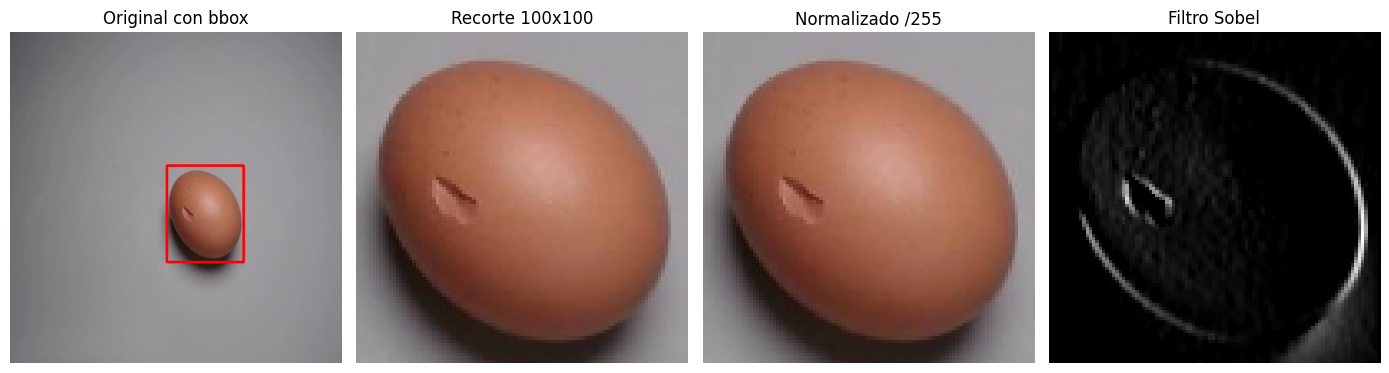

In [23]:
# Inspección visual: bbox original, recorte, normalización y Sobel.
def first_example(split='train', label='crack'):
    split_dir = DATASET_DIR / split
    annotation_path = find_annotation_file(split_dir)
    with annotation_path.open(encoding='utf-8') as file:
        coco = json.load(file)
    categories = {item['id']: item['name'].lower() for item in coco['categories']}
    images = {item['id']: item for item in coco['images']}
    for annotation in coco['annotations']:
        current = categories.get(annotation['category_id'], '')
        if label in current:
            info = images[annotation['image_id']]
            path = find_image(split_dir, info['file_name'])
            image_bgr = cv2.imread(str(path))
            image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
            x, y, width, height = map(int, annotation['bbox'])
            boxed = image_rgb.copy()
            cv2.rectangle(boxed, (x, y), (x + width, y + height), (255, 0, 0), 3)
            crop = crop_from_bbox(image_bgr, annotation['bbox'])
            gray = cv2.cvtColor(crop, cv2.COLOR_RGB2GRAY)
            sobel = cv2.filter2D(gray, -1, np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float32))
            return boxed, crop, crop.astype(np.float32) / 255.0, sobel
    return None

example = first_example()
if example:
    titles = ['Original con bbox', 'Recorte 100x100', 'Normalizado /255', 'Filtro Sobel']
    plt.figure(figsize=(14, 4))
    for index, (title, image) in enumerate(zip(titles, example), 1):
        plt.subplot(1, 4, index)
        plt.imshow(image, cmap='gray' if index == 4 else None)
        plt.title(title)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

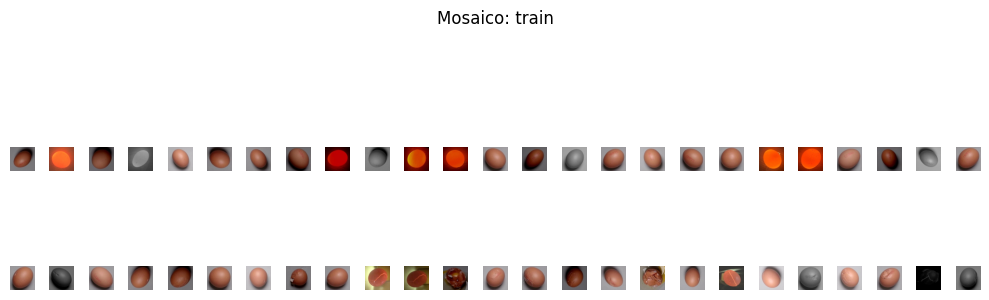

clase,crack,good
split,,
test,62,65
train,641,597
valid,58,65


Si hay un desbalance importante, se puede usar class_weight o augmentation dirigida a la clase minoritaria.


In [24]:
# Mosaico de ejemplos y balance por split.
def show_mosaic(split='train', per_class=25):
    plt.figure(figsize=(10, 4))
    for row, label in enumerate(CLASS_NAMES):
        files = list((Path('/content/crops') / split / label).glob('*.jpg'))[:per_class]
        for column, path in enumerate(files):
            image = cv2.cvtColor(cv2.imread(str(path)), cv2.COLOR_BGR2RGB)
            axis = plt.subplot(2, per_class, row * per_class + column + 1)
            axis.imshow(image)
            axis.axis('off')
            if column == 0:
                axis.set_ylabel(label)
    plt.suptitle(f'Mosaico: {split}')
    plt.tight_layout()
    plt.show()

show_mosaic()
balance = []
for split in ['train', 'valid', 'test']:
    for label in CLASS_NAMES:
        balance.append({'split': split, 'clase': label, 'imagenes': len(list((Path('/content/crops') / split / label).glob('*.jpg')))})
balance_df = pd.DataFrame(balance)
display(balance_df.pivot(index='split', columns='clase', values='imagenes'))
print('Si hay un desbalance importante, se puede usar class_weight o augmentation dirigida a la clase minoritaria.')

## 3. Carga, normalización y augmentation
`image_dataset_from_directory` produce etiquetas enteras, por eso usaremos `sparse_categorical_crossentropy`. `prefetch` solapa la preparación de lotes con el entrenamiento. La augmentation agrega variaciones pequeñas para combatir el sobreajuste con un dataset reducido.

In [25]:
from pathlib import Path

print("Dataset original:")
for p in DATASET_DIR.iterdir():
    print("-", p.name)

print("\nCrops generados:")
crops_dir = Path("/content/crops")
if crops_dir.exists():
    for p in crops_dir.iterdir():
        print("-", p.name)

Dataset original:
- README.roboflow.txt
- README.dataset.txt
- train

Crops generados:
- test
- all
- valid
- train


In [26]:
from pathlib import Path
import shutil
import random

random.seed(42)

CROPS_DIR = Path("/content/crops")
TRAIN_DIR = CROPS_DIR / "train"

# Guardamos la carpeta original con todos los crops
ALL_DIR = CROPS_DIR / "all"

if not ALL_DIR.exists():
    TRAIN_DIR.rename(ALL_DIR)

# Identificar la imagen original de la que salió cada crop
# Los nombres tienen formato: nombre_imagen_IDANOTACION.jpg
groups = {}

for label in ["good", "crack"]:
    label_dir = ALL_DIR / label

    for file in label_dir.glob("*.jpg"):
        original_image = file.stem.rsplit("_", 1)[0]

        if original_image not in groups:
            groups[original_image] = []

        groups[original_image].append((file, label))

# Dividir POR IMAGEN ORIGINAL para evitar data leakage
image_groups = list(groups.keys())
random.shuffle(image_groups)

n = len(image_groups)

train_end = int(n * 0.80)
valid_end = int(n * 0.90)

split_groups = {
    "train": image_groups[:train_end],
    "valid": image_groups[train_end:valid_end],
    "test": image_groups[valid_end:]
}

# Crear carpetas
for split in ["train", "valid", "test"]:
    for label in ["good", "crack"]:
        (CROPS_DIR / split / label).mkdir(parents=True, exist_ok=True)

# Copiar crops respetando la división por imagen original
for split, group_names in split_groups.items():

    for group_name in group_names:

        for source_file, label in groups[group_name]:

            destination = CROPS_DIR / split / label / source_file.name
            shutil.copy2(source_file, destination)

print("División completada.\n")

for split in ["train", "valid", "test"]:

    good = len(list((CROPS_DIR / split / "good").glob("*.jpg")))
    crack = len(list((CROPS_DIR / split / "crack").glob("*.jpg")))

    print(
        f"{split}: "
        f"good={good}, "
        f"crack={crack}, "
        f"total={good + crack}"
    )

División completada.

train: good=597, crack=641, total=1238
valid: good=65, crack=58, total=123
test: good=65, crack=62, total=127


In [27]:
def load_split(split, shuffle):
    return tf.keras.utils.image_dataset_from_directory(
        Path('/content/crops') / split,
        labels='inferred',
        label_mode='int',
        class_names=CLASS_NAMES,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        seed=SEED,
    )

train_raw = load_split('train', True)
valid_raw = load_split('valid', False)
test_raw = load_split('test', False)

normalization = tf.keras.layers.Rescaling(1.0 / 255)
augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.08),
    tf.keras.layers.RandomZoom(0.10),
], name='augmentation')
AUTOTUNE = tf.data.AUTOTUNE

# Augmentation SOLO en entrenamiento (rotar, voltear, zoom) para crear variaciones
# con un dataset reducido (408 imágenes) y reducir el sobreajuste. NUNCA en valid/test
# porque la evaluación debe verse con datos reales, sin transformaciones.
def preprocess_train(images, labels):
    return augmentation(normalization(images)), labels

def preprocess_eval(images, labels):
    return normalization(images), labels

train_ds = train_raw.map(preprocess_train, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
valid_ds = valid_raw.map(preprocess_eval, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
test_ds = test_raw.map(preprocess_eval, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

Found 1238 files belonging to 2 classes.
Found 123 files belonging to 2 classes.
Found 127 files belonging to 2 classes.


## 4. Modelo MLP
`Flatten` convierte cada imagen en un vector. Las capas densas aprenden combinaciones globales de píxeles; ReLU se usa en las capas ocultas y softmax entrega una probabilidad por clase.

## 5. Modelo CNN
Las convoluciones detectan bordes y patrones locales reutilizando filtros. MaxPooling reduce la resolución conservando señales dominantes. Dropout apaga unidades durante el entrenamiento y ayuda a limitar el sobreajuste.

## 5b. Transfer learning: MobileNetV2
Con solo ~408 imágenes, entrenar una CNN desde cero es frágil. El **transfer learning** reutiliza una red ya entrenada en millones de fotos (ImageNet), congela sus capas de extracción de features y solo entrena la cabeza clasificadora. Casi siempre supera a una CNN desde cero con pocos datos y es la práctica estándar en producción.

In [28]:
# Configuración de ambos modelos y su entrenamiento.
# Callbacks compartidos: EarlyStopping (evita sobreajuste), ReduceLROnPlateau
# (afina cuando la pérdida se estanca) y ModelCheckpoint (guarda mejor val_loss).
def callbacks_for(path):
    return [
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, min_lr=1e-6),
        tf.keras.callbacks.ModelCheckpoint(path, monitor='val_loss', save_best_only=True),
    ]

# Modelo 1: red densa (MLP). Flatten pasa la imagen (100x100x3) a un vector;
# las capas densas aprenden combinaciones globales de píxeles. Es la línea base
# (una imagen de 30.000 valores no debería clasificarse con densas puras).
mlp = tf.keras.Sequential([
    tf.keras.Input(shape=(*IMG_SIZE, 3)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(2, activation='softmax'),
], name='mlp')
mlp.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
mlp.summary()

# Modelo 2: CNN. Las convoluciones detectan bordes y patrones locales reutilizando
# filtros; MaxPooling reduce la resolución conservando las señales dominantes;
# Dropout apaga unidades al azar y reduce el sobreajuste (408 imágenes es poco).
cnn = tf.keras.Sequential([
    tf.keras.Input(shape=(*IMG_SIZE, 3)),
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(2, activation='softmax'),
], name='cnn')
cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
cnn.summary()

# Entrenamiento con medición de tiempo. El profe valora el PORQUÉ, no solo el qué:
# la CNN puede tardar más por época, pero con menos parámetros por patrón local.
EPOCHS = 50

start_mlp = time.time()
history_mlp = mlp.fit(
    train_ds, validation_data=valid_ds, epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=callbacks_for('/content/mejor_mlp.keras'), verbose=1,
)
elapsed_mlp = time.time() - start_mlp
print(f'MLP entrenado en {elapsed_mlp:.1f} s')

start_cnn = time.time()
history_cnn = cnn.fit(
    train_ds, validation_data=valid_ds, epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=callbacks_for('/content/mejor_cnn.keras'), verbose=1,
)
elapsed_cnn = time.time() - start_cnn
print(f'CNN entrenada en {elapsed_cnn:.1f} s')

# Modelo 3: Transfer learning con MobileNetV2 (pre-entrenada en ImageNet).
# Con solo 408 imágenes, reutilizar pesos ya aprendidos en millones de fotos
# casi siempre gana a entrenar una CNN desde cero. Congelamos el extractor de
# características y entrenamos solo la cabeza densa (fine-tuning opcional).
# La primera capa Rescaling pasa de [0,1] a [-1,1] (preprocesamiento de MobileNetV2)
# para que el contrato de datos (0-1) se mantenga igual en los 3 modelos.
base_mobilenet = tf.keras.applications.MobileNetV2(
    include_top=False, weights='imagenet', input_shape=(*IMG_SIZE, 3))
base_mobilenet.trainable = False  # transfer learning: pesos congelados
mobilenet = tf.keras.Sequential([
    tf.keras.Input(shape=(*IMG_SIZE, 3)),
    tf.keras.layers.Rescaling(2.0, offset=-1.0),  # [0,1] -> [-1,1]
    base_mobilenet,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(2, activation='softmax'),
], name='mobilenetv2')
mobilenet.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
mobilenet.summary()

start_mobilenet = time.time()
history_mobilenet = mobilenet.fit(
    train_ds, validation_data=valid_ds, epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=callbacks_for('/content/mejor_mobilenet.keras'), verbose=1,
)
elapsed_mobilenet = time.time() - start_mobilenet
print(f'MobileNetV2 (transfer learning) entrenada en {elapsed_mobilenet:.1f} s')


Model: "mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 30000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │     3,840,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,850,530 (14.69 MB)

 Trainable params: 3,850,530 (14.69 MB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_3 (Rescaling)         │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,340,098 (8.93 MB)

 Trainable params: 82,114 (320.76 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 30s 549ms/step - accuracy: 0.7084 - loss: 0.6383 - val_accuracy: 0.8211 - val_loss: 0.3457 - learning_rate: 0.0010
Epoch 2/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - accuracy: 0.8498 - loss: 0.3133 - val_accuracy: 0.8049 - val_loss: 0.3210 - learning_rate: 0.0010
Epoch 3/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - accuracy: 0.8869 - loss: 0.2709 - val_accuracy: 0.7724 - val_loss: 0.3916 - learning_rate: 0.0010
Epoch 4/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 4s 94ms/step - accuracy: 0.8861 - loss: 0.2499 - val_accuracy: 0.8699 - val_loss: 0.2376 - learning_rate: 0.0010
Epoch 5/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - accuracy: 0.8982 - loss: 0.2493 - val_accuracy: 0.7967 - val_loss: 0.3837 - learning_rate: 0.0010
Epoch 6/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - accuracy: 0.8966 - loss: 0.2280 - val_accuracy: 0.9187 - val_loss: 0.2034 - learning_rate: 0.0010
Epoch 7/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.9095 - loss: 0.2176 - val_a

## 6. Evaluación comparativa
Se comparan accuracy y **recall de `crack`**: un huevo agrietado que pasa por bueno
es el error más caro del negocio, por eso el recall de `crack` manda en la decisión final.


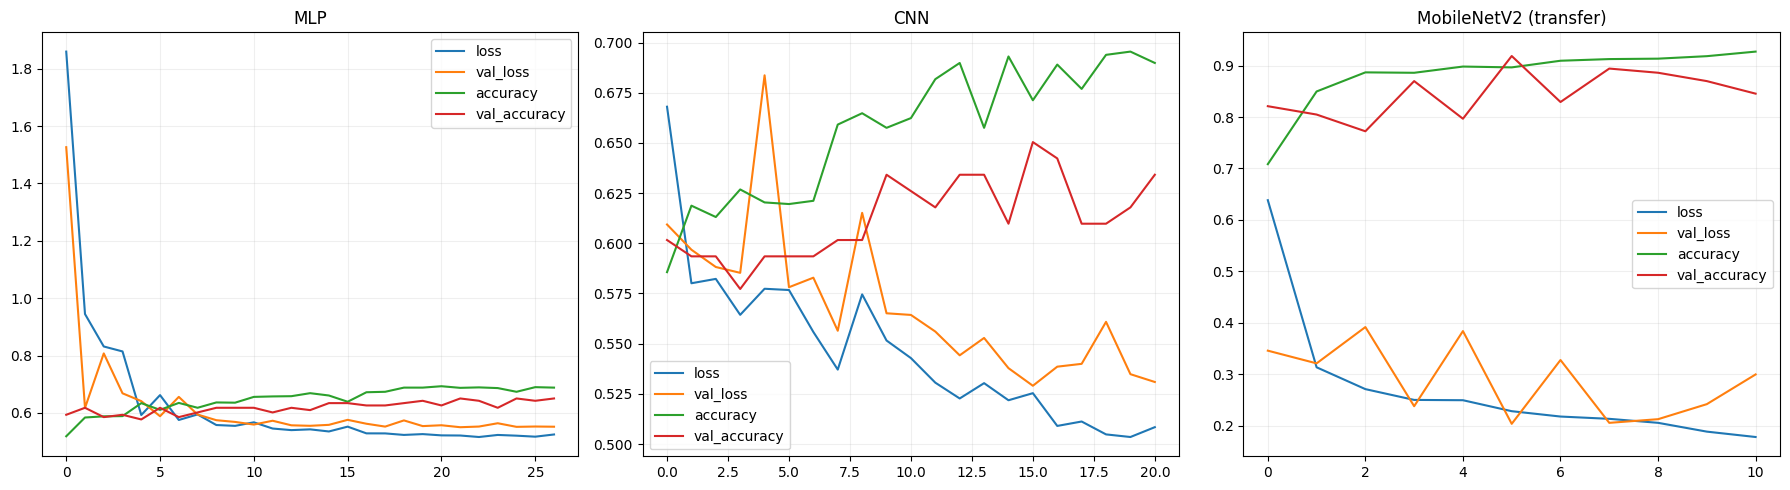


=== MLP ===
loss=0.5069 accuracy=0.7480 recall_crack=0.8226 tiempo=78.2s
              precision    recall  f1-score   support

        good       0.80      0.68      0.73        65
       crack       0.71      0.82      0.76        62

    accuracy                           0.75       127
   macro avg       0.75      0.75      0.75       127
weighted avg       0.76      0.75      0.75       127



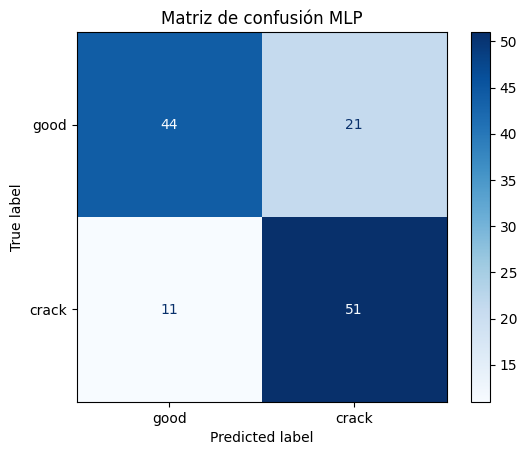


=== CNN ===
loss=0.5035 accuracy=0.7165 recall_crack=0.6452 tiempo=66.1s
              precision    recall  f1-score   support

        good       0.70      0.78      0.74        65
       crack       0.74      0.65      0.69        62

    accuracy                           0.72       127
   macro avg       0.72      0.71      0.71       127
weighted avg       0.72      0.72      0.71       127



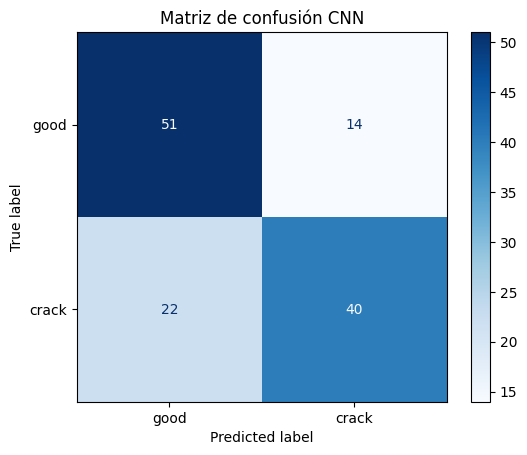


=== MobileNetV2 ===
loss=0.1639 accuracy=0.9449 recall_crack=0.9516 tiempo=60.1s
              precision    recall  f1-score   support

        good       0.95      0.94      0.95        65
       crack       0.94      0.95      0.94        62

    accuracy                           0.94       127
   macro avg       0.94      0.95      0.94       127
weighted avg       0.95      0.94      0.94       127



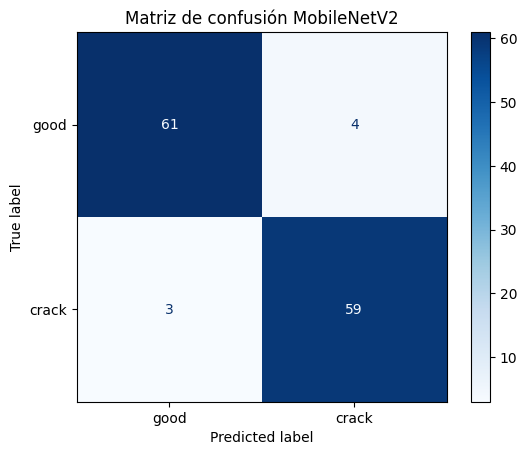

In [29]:
def plot_history(history, title):
    plt.plot(history.history['loss'], label='loss')
    plt.plot(history.history['val_loss'], label='val_loss')
    plt.plot(history.history['accuracy'], label='accuracy')
    plt.plot(history.history['val_accuracy'], label='val_accuracy')
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.2)

plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
plot_history(history_mlp, 'MLP')
plt.subplot(1, 3, 2)
plot_history(history_cnn, 'CNN')
plt.subplot(1, 3, 3)
plot_history(history_mobilenet, 'MobileNetV2 (transfer)')
plt.tight_layout()
plt.show()

def evaluate_model(model, name, elapsed):
    loss, accuracy = model.evaluate(test_ds, verbose=0)
    y_true = np.concatenate([labels.numpy() for _, labels in test_ds])
    probabilities = model.predict(test_ds, verbose=0)
    y_pred = probabilities.argmax(axis=1)
    recall_crack = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
    print(f'\n=== {name} ===')
    print(f'loss={loss:.4f} accuracy={accuracy:.4f} recall_crack={recall_crack:.4f} tiempo={elapsed:.1f}s')
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0))
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
    disp.plot(cmap='Blues')
    plt.title(f'Matriz de confusión {name}')
    plt.show()
    return [{'accuracy': float(accuracy), 'recall_crack': float(recall_crack),
             'elapsed_s': float(elapsed), 'y_true': y_true, 'y_pred': y_pred}]

mlp_result = evaluate_model(mlp, 'MLP', elapsed_mlp)
cnn_result = evaluate_model(cnn, 'CNN', elapsed_cnn)
mobilenet_result = evaluate_model(mobilenet, 'MobileNetV2', elapsed_mobilenet)


In [30]:
# Se elige el modelo con mayor accuracy ENTRE los que aseguran un buen recall de crack (>= 0.85).
# El recall de crack sigue siendo el criterio de negocio (no dejar pasar huevos rotos), pero
# sin sacrificar la clasificacion de los buenos: un modelo que predice crack casi siempre tiene
# recall alto pero es inutil en la practica (la CNN del analisis previo tenia recall 0.90 pero
# accuracy 0.64 y solo acertaba 38% de los huevos buenos).
results = {
    'MLP': mlp_result[0],
    'CNN': cnn_result[0],
    'MobileNetV2': mobilenet_result[0],
}
models = {'MLP': mlp, 'CNN': cnn, 'MobileNetV2': mobilenet}
MIN_RECALL_CRACK = 0.85
candidates = {k: r for k, r in results.items() if r['recall_crack'] >= MIN_RECALL_CRACK}
best_name = max(candidates, key=lambda k: candidates[k]['accuracy']) if candidates else max(results, key=lambda k: results[k]['recall_crack'])
best_model = models[best_name]
best_recall = results[best_name]['recall_crack']
print(f'Mejor modelo: {best_name} (accuracy={results[best_name]["accuracy"]:.4f}, recall_crack={best_recall:.4f})')


Mejor modelo: MobileNetV2 (accuracy=0.9449, recall_crack=0.9516)


In [31]:
# Persistencia y contrato para la VM: RGB, recorte, 100x100 y /255.
best_path = {'MLP': '/content/mejor_mlp.keras', 'CNN': '/content/mejor_cnn.keras', 'MobileNetV2': '/content/mejor_mobilenet.keras'}[best_name]
export_dir = DRIVE_DIR / 'models'
export_dir.mkdir(parents=True, exist_ok=True)
shutil.copy2(best_path, export_dir / Path(best_path).name)
with (export_dir / 'clases.json').open('w', encoding='utf-8') as file:
    json.dump(CLASS_NAMES, file, ensure_ascii=False, indent=2)
preprocessing = {
    'crop_size': [100, 100],
    'scale': '/255',
    'color_format': 'RGB',
    'bbox_margin': 0.04,
}
with (export_dir / 'preprocesamiento.json').open('w', encoding='utf-8') as file:
    json.dump(preprocessing, file, ensure_ascii=False, indent=2)
zip_base = '/content/egg_quality_models'
zip_path = shutil.make_archive(zip_base, 'zip', export_dir)
shutil.copy2(zip_path, DRIVE_DIR / 'egg_quality_models.zip')
print('Modelo exportado a Drive:', export_dir)
print('Zip:', DRIVE_DIR / 'egg_quality_models.zip')


Modelo exportado a Drive: /content/drive/MyDrive/egg_quality/models
Zip: /content/drive/MyDrive/egg_quality/egg_quality_models.zip


In [32]:
# Para la VM: descargar egg_quality_models.zip, descomprimir y cargar el modelo.
# 1. Descarga desde Drive (gdown con el id del archivo o descarga manual).
# 2. Descomprime: unzip egg_quality_models.zip -d egg_quality_models
# 3. Instala: pip install tensorflow fastapi uvicorn pillow
# 4. Carga y prueba:
#    import tensorflow as tf
#    model = tf.keras.models.load_model('mejor_cnn.keras')
#    print(model.summary())
